# 12장 - LangGraph 메모리

원본 파일: `chap12/langgraph_memory.py`

In [8]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from dotenv import load_dotenv
import os

load_dotenv()

model = ChatOpenAI(
    model="openai/gpt-4o-mini",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv('OPENAI_API_KEY'),
)

In [9]:
class State(TypedDict):
    messages: Annotated[list[str], add_messages]

In [10]:
graph_builder = StateGraph(State)

In [11]:
def generate(state: State):
    return {"messages": [model.invoke(state["messages"])]}

In [12]:
graph_builder.add_node("generate", generate)
graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", END)

# 대화 내용을 자동으로 기억하는 메모리(체크포인터) 추가
memory = MemorySaver()
config = {"configurable": {"thread_id": "abcd"}}  # thread_id로 대화방을 구분
graph = graph_builder.compile(checkpointer=memory)

## 그래프 구조 시각화

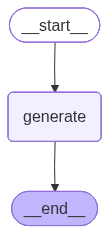

In [13]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # 실패 시 통과 (mermaid 렌더링 서버 접속 불가 등)
    pass

## 실행 / 테스트

In [14]:
while True:
    user_input = input("You\t:")

    if user_input in ["exit", "quit", "q"]:
        break

    for event in graph.stream({"messages": [HumanMessage(user_input)]}, config, stream_mode="values"):
        event["messages"][-1].pretty_print()

    print(f'\n현재 메시지 갯수: {len(event["messages"])}\n------------------\n')

================================ Human Message =================================

ㅓ
================================== Ai Message ==================================

안녕하세요! 어떻게 도와드릴까요?

현재 메시지 갯수: 2
------------------



KeyboardInterrupt: Interrupted by user